# NOTEBOOK: 01_modelado_segmentacion_clientes.ipynb
# PROYECTO FINAL: MINERÍA DE DATOS APLICADA - E-BUYSUR S.A.
# FASE 2 (TRANSFORMACIÓN) Y FASE 3 (MODELADO E HIPERPARÁMETROS)

## 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN

In [1]:
# ------------------------------------------------------------------------------
# 1. IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN
# ------------------------------------------------------------------------------
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Configuración de estilos visuales para los informes de la entrega
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

## 2. CARGA DEL DATASET GENERADO (FASE 1)

In [2]:
# ------------------------------------------------------------------------------
# 2. CARGA DEL DATASET GENERADO (FASE 1)
# ------------------------------------------------------------------------------
# Definimos la ruta relativa apuntando a la carpeta de datos según la estructura
ruta_dataset = os.path.join('..', 'dataset', 'dataset_clientes_ebuysur.csv')

# Validamos la existencia del archivo antes de la lectura
if os.path.exists(ruta_dataset):
    df_clientes = pd.read_csv(ruta_dataset)
    print(f"¡Éxito! Dataset cargado correctamente desde: {ruta_dataset}")
    print(f"Dimensiones del registro: {df_clientes.shape[0]} filas y {df_clientes.shape[1]} columnas.\n")
else:
    raise FileNotFoundError(f"No se encontró el archivo en {ruta_dataset}. Verifica la ejecución del script anterior.")

¡Éxito! Dataset cargado correctamente desde: ..\dataset\dataset_clientes_ebuysur.csv
Dimensiones del registro: 1000 filas y 3 columnas.



## 3. PREPROCESAMIENTO: TRANSFORMACIÓN Y ESCALADO (FASE 2)

In [3]:
# ------------------------------------------------------------------------------
# 3. PREPROCESAMIENTO: TRANSFORMACIÓN Y ESCALADO (FASE 2)
# ------------------------------------------------------------------------------
# Extracción de las variables métricas comerciales (excluyendo el ID alfanumérico)
features = ['Frecuencia_Compra', 'Monto_Anual_Gastado']
X = df_clientes[features].values

# Aplicamos la Estandarización Z-Score para equilibrar las escalas métricas
# Esto evita que el Monto Anual domine la métrica de distancia euclidiana
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Fase 2 Completada: Datos estandarizados mediante StandardScaler (Media=0, Varianza=1).")

Fase 2 Completada: Datos estandarizados mediante StandardScaler (Media=0, Varianza=1).


## 4. DETERMINACIÓN DEL HIPERPARÁMETRO K: MÉTODO DEL CODO (FASE 3)

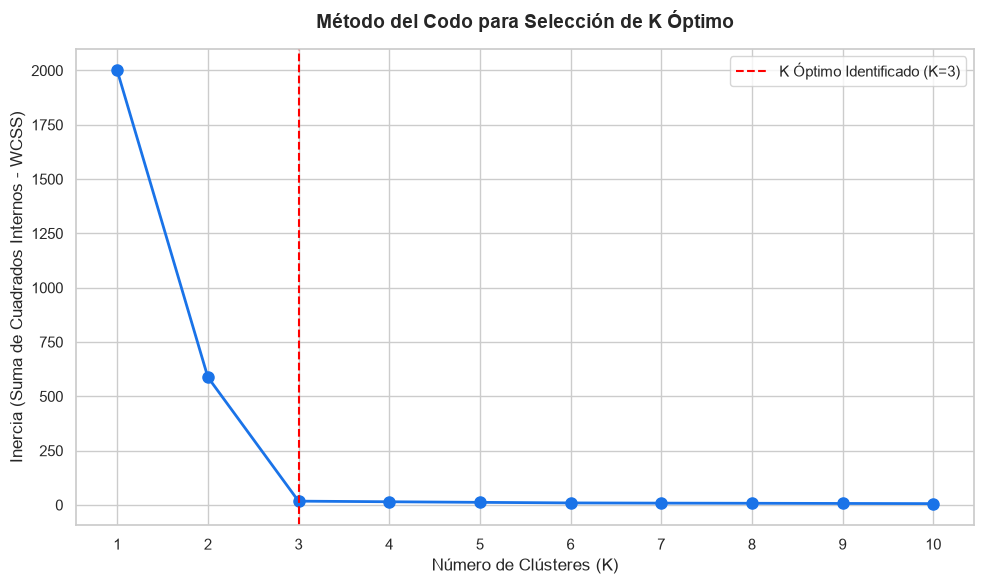

Gráfico del Método del Codo exportado con éxito en: ..\docs\grafico_metodo_codo.png


In [4]:
# ------------------------------------------------------------------------------
# 4. DETERMINACIÓN DEL HIPERPARÁMETRO K: MÉTODO DEL CODO (FASE 3)
# ------------------------------------------------------------------------------
inercia = []
valores_k = range(1, 11)

# Evaluamos la inercia (WCSS) desde K=1 hasta K=10
for k in valores_k:
    kmeans_prueba = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans_prueba.fit(X_scaled)
    inercia.append(kmeans_prueba.inertia_)

# Generación y guardado del gráfico del Método del Codo
plt.figure()
plt.plot(valores_k, inercia, marker='o', color='#1a73e8', linewidth=2, markersize=8)
plt.title('Método del Codo para Selección de K Óptimo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Número de Clústeres (K)', fontsize=12)
plt.ylabel('Inercia (Suma de Cuadrados Internos - WCSS)', fontsize=12)
plt.xticks(valores_k)
plt.axvline(x=3, color='red', linestyle='--', linewidth=1.5, label='K Óptimo Identificado (K=3)')
plt.legend(fontsize=11)
plt.tight_layout()

# Guardamos el gráfico en la carpeta de documentos para el informe Word
ruta_grafico_codo = os.path.join('..', 'docs', 'grafico_metodo_codo.png')
plt.savefig(ruta_grafico_codo, dpi=300)
plt.show()
print(f"Gráfico del Método del Codo exportado con éxito en: {ruta_grafico_codo}")

## 5. ENTRENAMIENTO DEFINITIVO DEL MODELO K-MEANS (K=3)

In [5]:
# ------------------------------------------------------------------------------
# 5. ENTRENAMIENTO DEFINITIVO DEL MODELO K-MEANS (K=3)
# ------------------------------------------------------------------------------
k_optimo = 3
modelo_kmeans = KMeans(n_clusters=k_optimo, init='k-means++', random_state=42, n_init=10)

# Ajustamos el modelo y realizamos la asignación de etiquetas de clústeres
df_clientes['Cluster'] = modelo_kmeans.fit_predict(X_scaled)

## 6. EVALUACIÓN ESTADÍSTICA: ANÁLISIS DE SILUETA (FASE 3)


MÉTRICA DE EVALUACIÓN GLOBAL (Silhouette Score): 0.9198



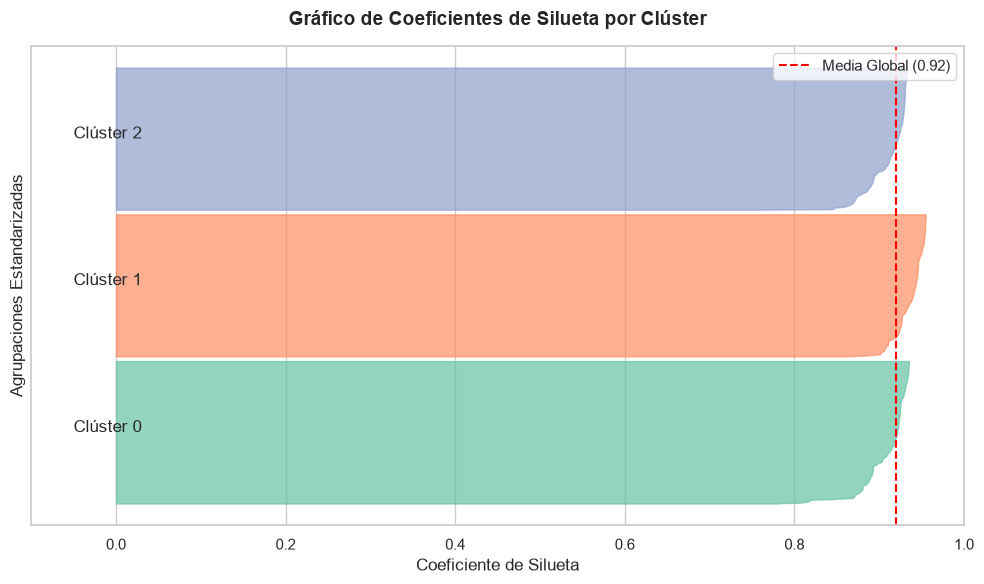

Gráfico de Análisis de Silueta exportado con éxito en: ..\docs\grafico_silueta.png


In [6]:
# ------------------------------------------------------------------------------
# 6. EVALUACIÓN ESTADÍSTICA: ANÁLISIS DE SILUETA (FASE 3)
# ------------------------------------------------------------------------------
# Cálculo del Coeficiente de Silueta Global
score_global = silhouette_score(X_scaled, df_clientes['Cluster'])
print("\n========================================================")
print(f"MÉTRICA DE EVALUACIÓN GLOBAL (Silhouette Score): {score_global:.4f}")
print("========================================================\n")

# Generación del gráfico de Silueta detallado por Clúster
fig, ax1 = plt.subplots(1, 1)
y_lower = 10
sample_silhouette_values = silhouette_samples(X_scaled, df_clientes['Cluster'])

for i in range(k_optimo):
    # Agrupamos y ordenamos los coeficientes de los elementos del clúster actual
    ith_cluster_silhouette_values = sample_silhouette_values[df_clientes['Cluster'] == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = sns.color_palette("Set2")[i]
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, f"Clúster {i}")
    y_lower = y_upper + 10

ax1.set_title("Gráfico de Coeficientes de Silueta por Clúster", fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel("Coeficiente de Silueta", fontsize=12)
ax1.set_ylabel("Agrupaciones Estandarizadas", fontsize=12)
ax1.axvline(x=score_global, color="red", linestyle="--", linewidth=1.5, label=f'Media Global ({score_global:.2f})')
ax1.set_yticks([])
ax1.set_xlim([-0.1, 1.0])
ax1.legend(fontsize=11, loc='upper right')
plt.tight_layout()

# Guardamos el gráfico de silueta para el reporte final
ruta_grafico_silueta = os.path.join('..', 'docs', 'grafico_silueta.png')
plt.savefig(ruta_grafico_silueta, dpi=300)
plt.show()
print(f"Gráfico de Análisis de Silueta exportado con éxito en: {ruta_grafico_silueta}")

## 7. EXPORTACIÓN DEL ARCHIVO FINAL CON ETIQUETAS

In [7]:
# ------------------------------------------------------------------------------
# 7. EXPORTACIÓN DEL ARCHIVO FINAL CON ETIQUETAS
# ------------------------------------------------------------------------------
# Guardamos los datos con la nueva columna 'Cluster' mapeada
ruta_salida = os.path.join('..', 'dataset', 'dataset_clientes_segmentados.csv')
df_clientes.to_csv(ruta_salida, index=False)
print(f"\n¡Proceso finalizado! Archivo de resultados guardado en: {ruta_salida}")


¡Proceso finalizado! Archivo de resultados guardado en: ..\dataset\dataset_clientes_segmentados.csv


In [8]:
print(df_clientes.groupby('Cluster')[['Frecuencia_Compra', 'Monto_Anual_Gastado']].mean())

         Frecuencia_Compra  Monto_Anual_Gastado
Cluster                                        
0                 9.781437        450937.976686
1                 2.726727         48549.125179
2                21.495495        273267.971144
